# Healthcare Analytics for Doctor Visits

### Introduction
This data analytics project explores a healthcare dataset to understand patterns in doctor visits. We will examine demographic factors, health-related indicators, illness metrics, insurance coverage, and chronic conditions to identify meaningful relationships and observations.

## 2. Problem Statement

Understanding what drives doctor visits is crucial for healthcare planning and resource allocation. Healthcare utilization patterns vary widely across demographic and health status dimensions. The purpose of this analysis is to identify patterns and relationships within the dataset to help understand which sub-populations utilize medical visits more frequently, without implying direct causation.

## 3. Objectives

- Understand the healthcare dataset and its variables.
- Clean and prepare the data for analysis.
- Analyze the distribution of doctor visits.
- Examine differences in doctor visits across demographic groups.
- Investigate relationships between illness, health conditions, and doctor visits.
- Examine the role of chronic conditions and healthcare-related variables.
- Apply descriptive statistics and visualization techniques.
- Identify meaningful patterns and unusual observations.
- Develop evidence-based insights and conclusions.

## 4. Import Libraries

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries successfully imported!")

Libraries successfully imported!


## 5. Load Dataset

In [36]:
df = pd.read_csv("1776250375-P2-Healthcare Analytics for Doctor Visits.csv")
print("Dataset loaded successfully!")
print(f"DataFrame Shape: {df.shape}")

print("\nFirst 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())

Dataset loaded successfully!
DataFrame Shape: (5190, 13)

First 5 rows:


,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
0,1,1,female,0.19,0.55,1,4,1,yes,no,no,no,no
1,2,1,female,0.19,0.45,1,2,1,yes,no,no,no,no
2,3,1,male,0.19,0.90,3,0,0,no,no,no,no,no
3,4,1,male,0.19,0.15,1,0,0,no,no,no,no,no
4,5,1,male,0.19,0.45,2,5,1,no,no,no,yes,no



Last 5 rows:


,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
5185,5186,0,female,0.22,0.55,0,0,0,no,no,no,no,no
5186,5187,0,male,0.27,1.30,0,0,1,no,no,no,no,no
5187,5188,0,female,0.37,0.25,1,0,1,no,no,yes,no,no
5188,5189,0,female,0.52,0.65,0,0,0,no,no,no,no,no
5189,5190,0,male,0.72,0.25,0,0,0,no,no,yes,no,no


## 6. Dataset Understanding

In [18]:
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset Info:")
df.info()

print("\nStatistical Summary:")
display(df.describe())

Number of rows: 5190
Number of columns: 13

Column names:
['Unnamed: 0', 'visits', 'gender', 'age', 'income', 'illness', 'reduced', 'health', 'private', 'freepoor', 'freerepat', 'nchronic', 'lchronic']

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5190 entries, 0 to 5189
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  5190 non-null   int64  
 1   visits      5190 non-null   int64  
 2   gender      5190 non-null   object 
 3   age         5190 non-null   float64
 4   income      5190 non-null   float64
 5   illness     5190 non-null   int64  
 6   reduced     5190 non-null   int64  
 7   health      5190 non-null   int64  
 8   private     5190 non-null   object 
 9   freepoor    5190 non-null   object 
 10  freerepat   5190 non-null   object 
 11  nchronic    5190 non-null   object 
 12  lchronic    5190 non-null   object 
dtypes: float64(2), int64(5), object(6)
memory usage: 527.2+ 

,Unnamed: 0,visits,age,income,illness,reduced,health
count,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000
mean,2595.500000,0.301734,0.406385,0.583160,1.431985,0.861850,1.217534
std,1498.368279,0.798134,0.204782,0.368907,1.384152,2.887628,2.124266
min,1.000000,0.000000,0.190000,0.000000,0.000000,0.000000,0.000000
25%,1298.250000,0.000000,0.220000,0.250000,0.000000,0.000000,0.000000
50%,2595.500000,0.000000,0.320000,0.550000,1.000000,0.000000,0.000000
75%,3892.750000,0.000000,0.620000,0.900000,2.000000,0.000000,2.000000
max,5190.000000,9.000000,0.720000,1.500000,5.000000,14.000000,12.000000


## 7. Data Cleaning and Preparation

In this section, we examine the dataset for missing values, duplicates, and redundant columns. Missing values were checked and no missing-value treatment was required. Duplicate records were also checked, and the redundant 'Unnamed: 0' index column was removed.

In [19]:
# Check missing values
missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values[missing_values > 0])

# Check duplicates
duplicate_count = df.duplicated().sum()
print(f"\nDuplicate record count: {duplicate_count}")

# Remove 'Unnamed: 0' because it is simply a redundant row index
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
    print("\nRemoved 'Unnamed: 0' as it was just a row/index identifier.")

print(f"Final DataFrame Shape after cleaning: {df.shape}")

Missing values per column:
Series([], dtype: int64)

Duplicate record count: 0

Removed 'Unnamed: 0' as it was just a row/index identifier.
Final DataFrame Shape after cleaning: (5190, 12)


## 8. Variable Understanding

We categorize variables into numerical and categorical types and inspect their properties.

In [20]:
numerical_vars = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_vars = df.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Numerical columns: {numerical_vars}")
print(f"Categorical columns: {categorical_vars}")

# Check unique values of categorical variables
for col in categorical_vars:
    print(f"Unique values in '{col}': {df[col].unique()}")

Numerical columns: ['visits', 'age', 'income', 'illness', 'reduced', 'health']
Categorical columns: ['gender', 'private', 'freepoor', 'freerepat', 'nchronic', 'lchronic']
Unique values in 'gender': ['female' 'male']
Unique values in 'private': ['yes' 'no']
Unique values in 'freepoor': ['no' 'yes']
Unique values in 'freerepat': ['no' 'yes']
Unique values in 'nchronic': ['no' 'yes']
Unique values in 'lchronic': ['no' 'yes']


## 9. Descriptive Statistical Analysis

In [37]:
# Descriptive stats with explicit calculations for range
stats_df = df[numerical_vars].describe().T
stats_df['range'] = stats_df['max'] - stats_df['min']
display(stats_df[['count', 'mean', '50%', 'std', 'min', 'max', 'range']].rename(columns={'50%': 'median'}))

# Calculate exact correlations to ensure numerical claims are verified
income_corr = df['income'].corr(df['visits'])
age_corr = df['age'].corr(df['visits'])
print(f"Correlation between Income and Visits: {income_corr:.4f}")
print(f"Correlation between Age and Visits: {age_corr:.4f}")

,count,mean,median,std,min,max,range
visits,5190.0,0.301734,0.00,0.798134,0.00,9.00,9.00
age,5190.0,0.406385,0.32,0.204782,0.19,0.72,0.53
income,5190.0,0.583160,0.55,0.368907,0.00,1.50,1.50
illness,5190.0,1.431985,1.00,1.384152,0.00,5.00,5.00
reduced,5190.0,0.861850,0.00,2.887628,0.00,14.00,14.00
health,5190.0,1.217534,0.00,2.124266,0.00,12.00,12.00


Correlation between Income and Visits: -0.0768
Correlation between Age and Visits: 0.1245


## 10. Univariate Analysis

We analyze individual key variables visually and descriptively.

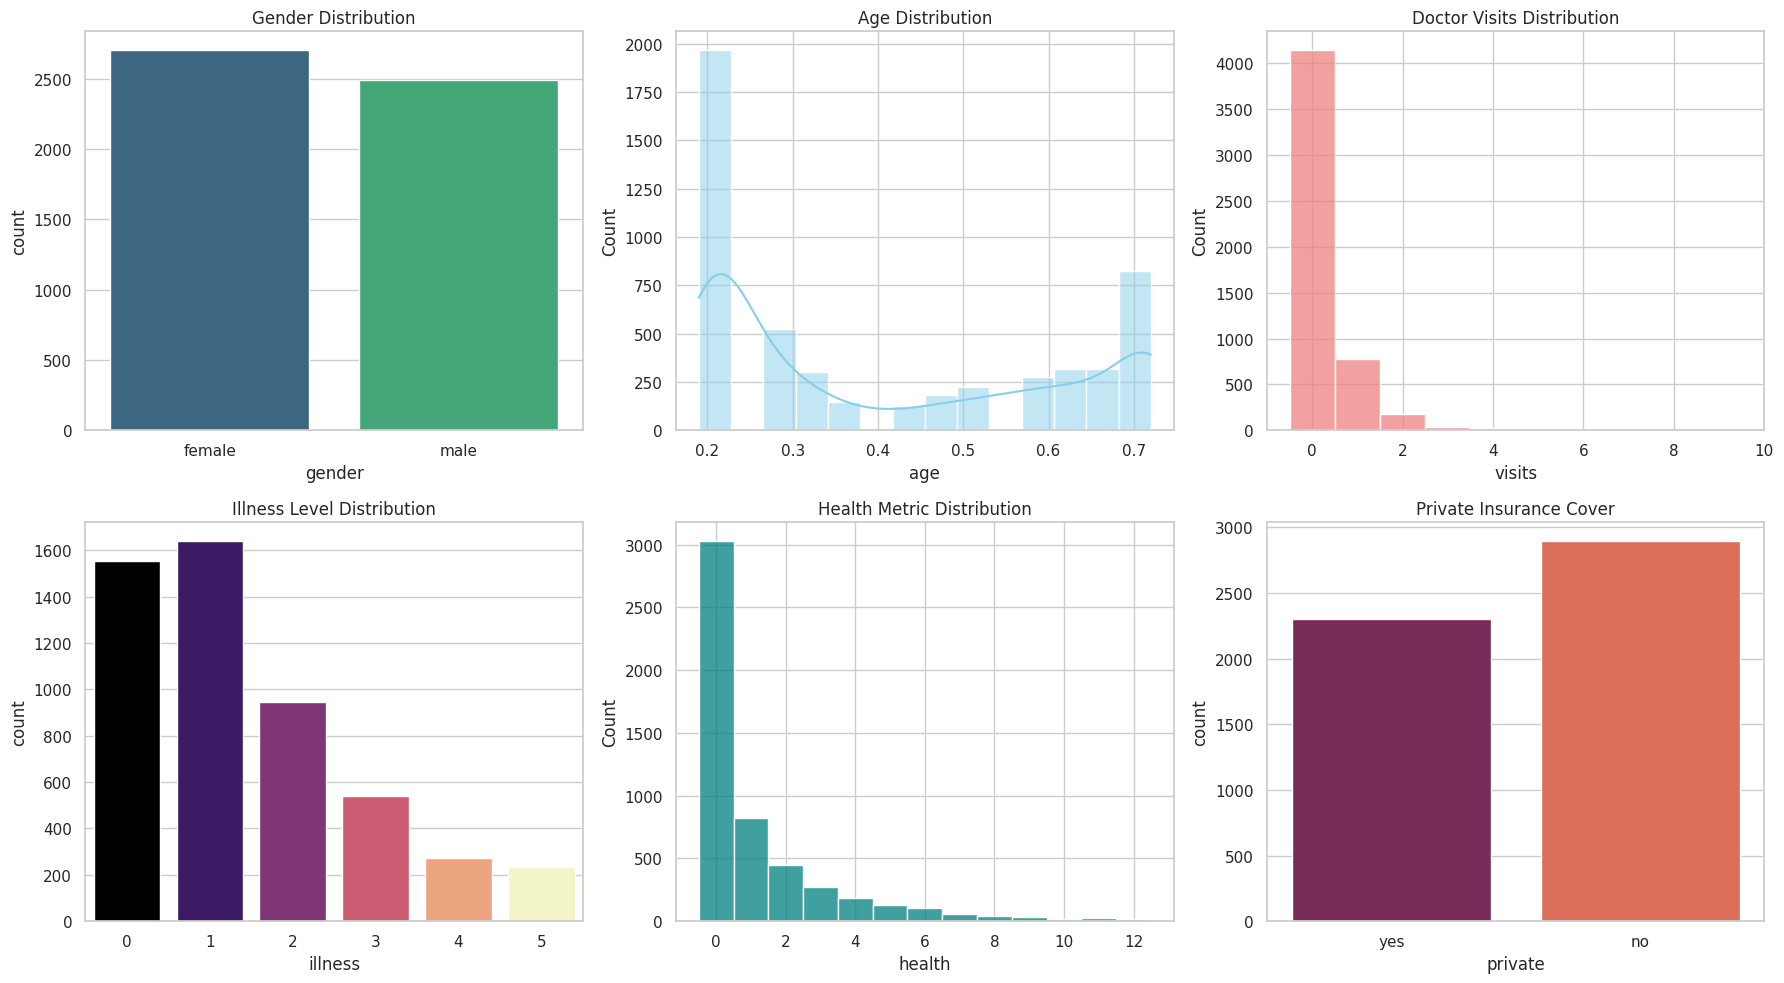

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Gender
sns.countplot(ax=axes[0,0], x='gender', data=df, palette='viridis', hue='gender', legend=False)
axes[0,0].set_title('Gender Distribution')

# 2. Age
sns.histplot(ax=axes[0,1], x='age', data=df, kde=True, color='skyblue')
axes[0,1].set_title('Age Distribution')

# 3. Doctor Visits
sns.histplot(ax=axes[0,2], x='visits', data=df, discrete=True, color='lightcoral')
axes[0,2].set_title('Doctor Visits Distribution')

# 4. Illness
sns.countplot(ax=axes[1,0], x='illness', data=df, palette='magma', hue='illness', legend=False)
axes[1,0].set_title('Illness Level Distribution')

# 5. Health
sns.histplot(ax=axes[1,1], x='health', data=df, discrete=True, color='teal')
axes[1,1].set_title('Health Metric Distribution')

# 6. Private Insurance
sns.countplot(ax=axes[1,2], x='private', data=df, palette='rocket', hue='private', legend=False)
axes[1,2].set_title('Private Insurance Cover')

plt.tight_layout()
plt.show()

### Interpretation of Univariate Analysis:
- **Gender**: The sample has a relatively balanced representation of males and females, with slightly more females.
- **Doctor Visits**: This distribution is heavily right-skewed, showing that a high proportion of people had 0 or 1 visit during the target period.
- **Age**: The distribution shows peaks at the younger and older spectrums of this normalized scale.

## 11. Bivariate Analysis

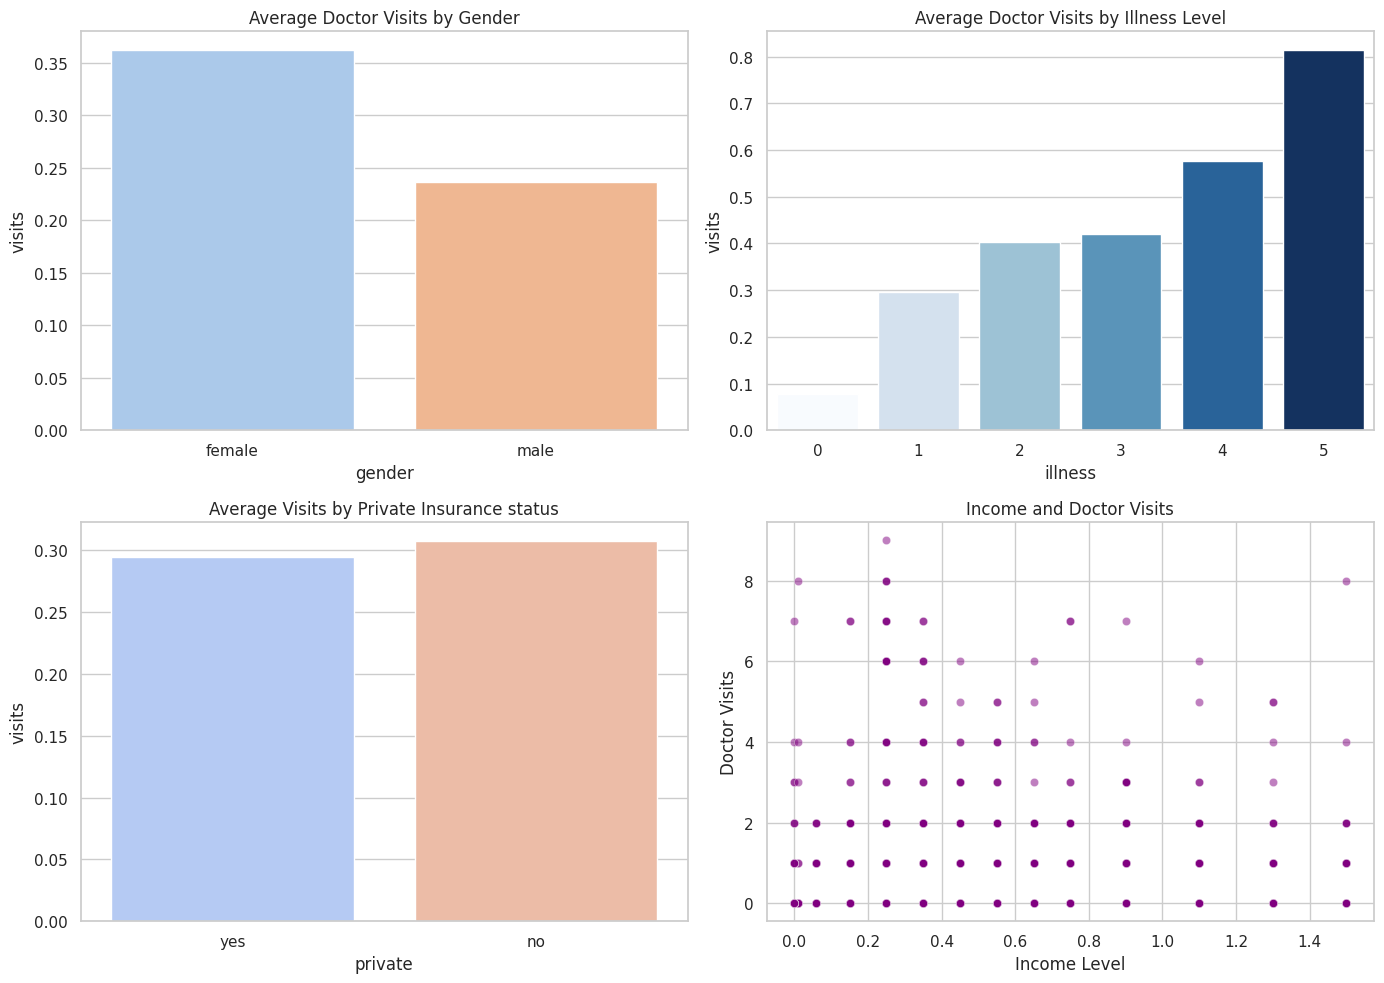

In [38]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gender vs Visits
sns.barplot(ax=axes[0,0], x='gender', y='visits', data=df, errorbar=None, palette='pastel', hue='gender', legend=False)
axes[0,0].set_title('Average Doctor Visits by Gender')

# Illness vs Visits
sns.barplot(ax=axes[0,1], x='illness', y='visits', data=df, errorbar=None, palette='Blues', hue='illness', legend=False)
axes[0,1].set_title('Average Doctor Visits by Illness Level')

# Private Insurance vs Visits
sns.barplot(ax=axes[1,0], x='private', y='visits', data=df, errorbar=None, palette='coolwarm', hue='private', legend=False)
axes[1,0].set_title('Average Visits by Private Insurance status')

# Income vs Visits - Scatter Plot for discrete/normalized income
sns.scatterplot(ax=axes[1,1], data=df, x='income', y='visits', alpha=0.5, color='purple')
axes[1,1].set_title('Income and Doctor Visits')
axes[1,1].set_xlabel('Income Level')
axes[1,1].set_ylabel('Doctor Visits')

plt.tight_layout()
plt.show()

### Interpretation of Bivariate Analysis:
- **Gender**: Female patients exhibit a higher average number of doctor visits compared to male patients in this sample.
- **Illness**: As the self-reported illness level increases, the average number of doctor visits is observed to rise.
- **Income Level**: The scatter plot shows doctor visits distributed across the normalized income levels with no obvious strong linear trend, suggesting that visitation patterns vary widely across all income cohorts without a direct continuous trend.

## 12. Multivariate Analysis

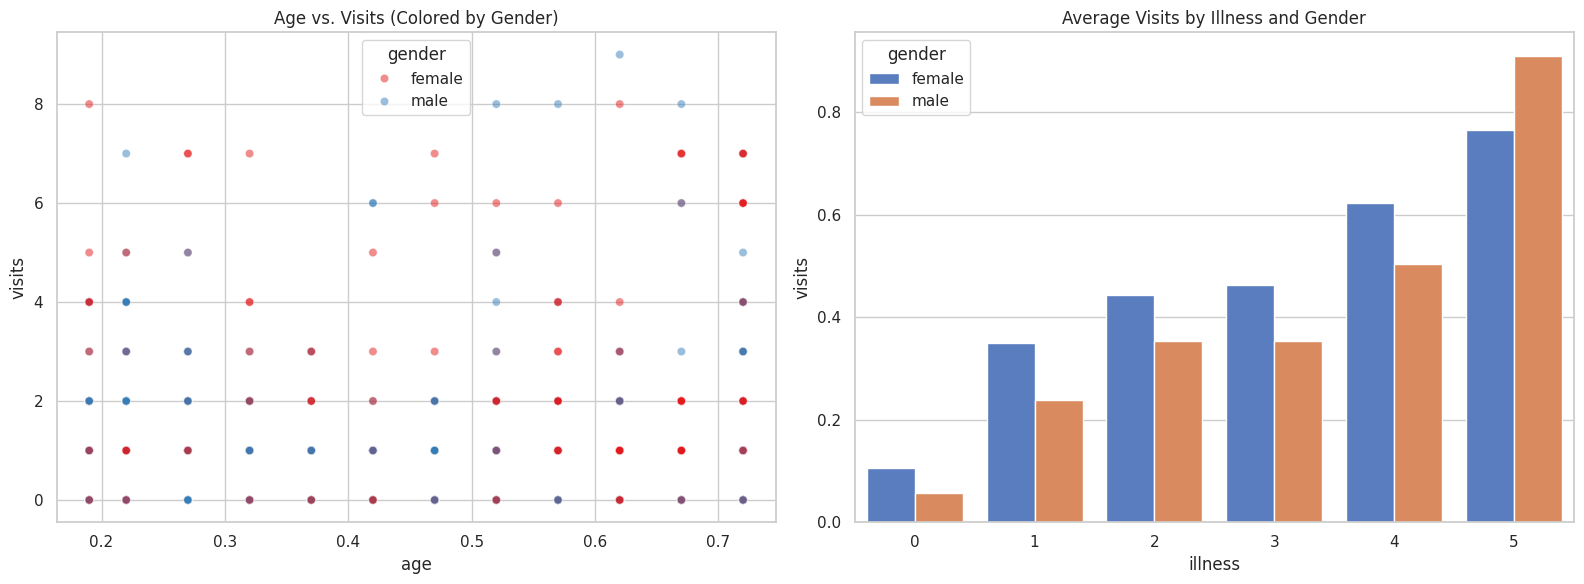

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Age vs. Doctor Visits by Gender
sns.scatterplot(ax=axes[0], x='age', y='visits', hue='gender', data=df, alpha=0.5, palette='Set1')
axes[0].set_title('Age vs. Visits (Colored by Gender)')

# 2. Illness vs. Doctor Visits by Gender
sns.barplot(ax=axes[1], x='illness', y='visits', hue='gender', data=df, errorbar=None, palette='muted')
axes[1].set_title('Average Visits by Illness and Gender')

plt.tight_layout()
plt.show()

### Interpretation of Multivariate Analysis:
- When examining the interaction of Illness and Gender with respect to Visits, we notice that for almost all illness levels, females maintain a higher average number of visits than males.

## 13. Chronic Condition Analysis

,nchronic,lchronic,count,mean,std
0,no,no,2493,0.191737,0.620784
1,no,yes,605,0.603306,1.195184
2,yes,no,2092,0.345602,0.816242


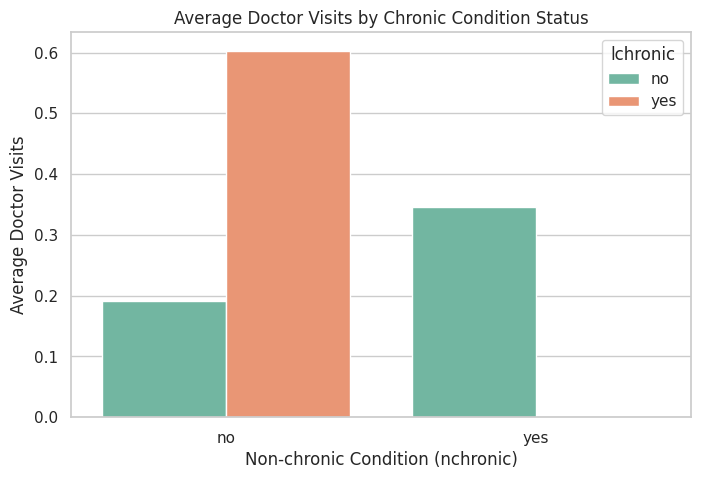

In [25]:
# Aggregate visits by nchronic and lchronic
chronic_summary = df.groupby(['nchronic', 'lchronic'])['visits'].agg(['count', 'mean', 'std']).reset_index()
display(chronic_summary)

plt.figure(figsize=(8, 5))
sns.barplot(x='nchronic', y='visits', hue='lchronic', data=df, errorbar=None, palette='Set2')
plt.title('Average Doctor Visits by Chronic Condition Status')
plt.xlabel('Non-chronic Condition (nchronic)')
plt.ylabel('Average Doctor Visits')
plt.show()

### Interpretation of Chronic Condition Analysis:
- Having chronic conditions (especially those represented by `lchronic == 'yes'`) appears to be associated with a higher mean rate of doctor visits, regardless of the `nchronic` status.

## 14. Healthcare Access / Coverage Analysis

,private,freepoor,freerepat,count,mean
0,no,no,no,1579,0.218493
1,no,no,yes,1091,0.466544
2,no,yes,no,222,0.157658
3,yes,no,no,2298,0.294604


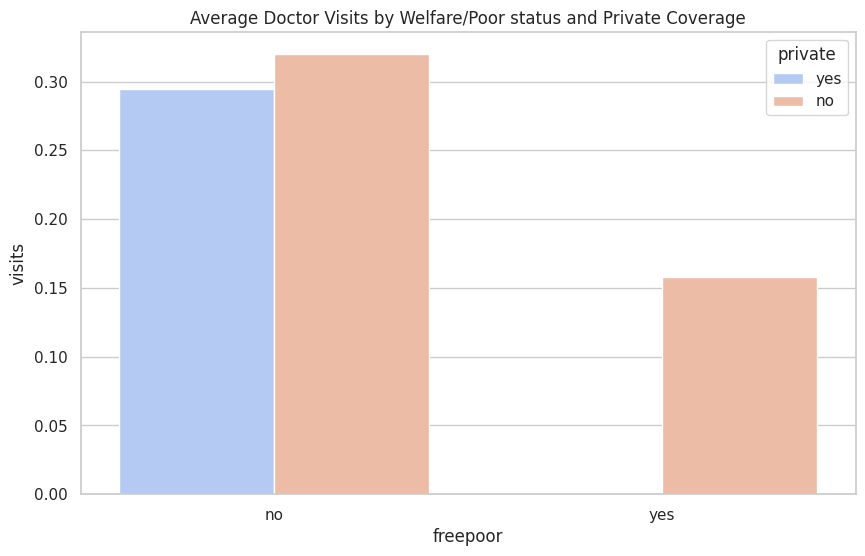

In [26]:
coverage_summary = df.groupby(['private', 'freepoor', 'freerepat'])['visits'].agg(['count', 'mean']).reset_index()
display(coverage_summary)

plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='freepoor', y='visits', hue='private', errorbar=None, palette='coolwarm')
plt.title('Average Doctor Visits by Welfare/Poor status and Private Coverage')
plt.show()

### Interpretation:
The healthcare-support variables show differences in average doctor visits across coverage groups. The visualization focuses on welfare/poor status (`freepoor`) and private insurance (`private`), while the summary table also includes repatriate-support status (`freerepat`).

## 15. Correlation Analysis

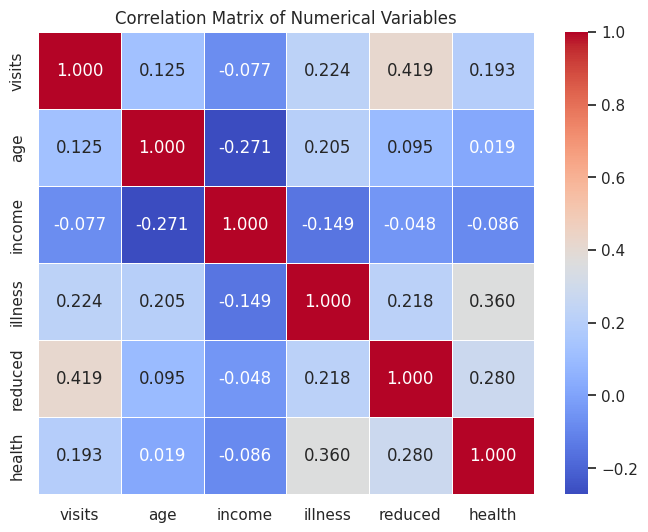

In [27]:
numeric_columns = df.select_dtypes(include=np.number).columns
corr = df[numeric_columns].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".3f", linewidths=0.5)
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

### Interpretation:
Most relationships with doctor visits are weak. Among the variables examined, reduced activity days (`reduced`, ~0.4190) and illness level (`illness`, ~0.2236) show the highest positive correlations with visits. Correlation describes association only and does not establish causation.

## 16. Outlier Analysis

VISITS -> Q1: 0.0, Q3: 0.0, IQR: 0.0, Lower: 0.00, Upper: 0.00, Potential Outliers Count: 1049
AGE -> Q1: 0.22, Q3: 0.62, IQR: 0.4, Lower: -0.38, Upper: 1.22, Potential Outliers Count: 0
INCOME -> Q1: 0.25, Q3: 0.9, IQR: 0.65, Lower: -0.73, Upper: 1.88, Potential Outliers Count: 0
ILLNESS -> Q1: 0.0, Q3: 2.0, IQR: 2.0, Lower: -3.00, Upper: 5.00, Potential Outliers Count: 0
HEALTH -> Q1: 0.0, Q3: 2.0, IQR: 2.0, Lower: -3.00, Upper: 5.00, Potential Outliers Count: 303
REDUCED -> Q1: 0.0, Q3: 0.0, IQR: 0.0, Lower: 0.00, Upper: 0.00, Potential Outliers Count: 736


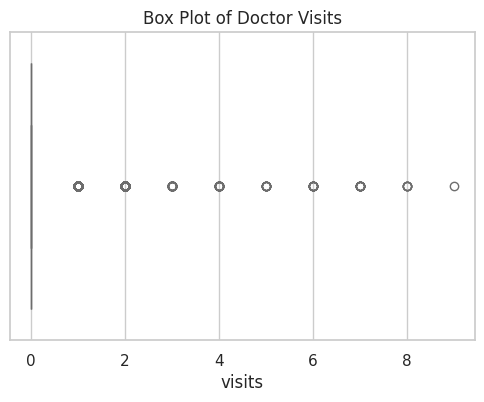

In [40]:
outlier_cols = ['visits', 'age', 'income', 'illness', 'health', 'reduced']

for col in outlier_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    potential_outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"{col.upper()} -> Q1: {q1}, Q3: {q3}, IQR: {iqr}, Lower: {lower_bound:.2f}, Upper: {upper_bound:.2f}, Potential Outliers Count: {len(potential_outliers)}")

plt.figure(figsize=(6, 4))
ns = sns.boxplot(x=df['visits'], color='salmon')
plt.title('Box Plot of Doctor Visits')
plt.show()

## 16.1. Outlier Interpretation

Because doctor visits are highly concentrated at zero, the IQR method flags positive visit counts as potential outliers. This indicates a strongly skewed distribution rather than necessarily incorrect observations. This same distinction applies when interpreting potential outliers in other heavily skewed variables (such as reduced activity days or the health metric).

### Analysis 1:

**Question**: How does the average doctor-visit frequency differ among groups with different levels of reduced activity (`reduced`)?

**Why Relevant**: Activity restriction provides an observational measure of functional limitation; analyzing this variable helps examine how different levels of reduced activity are associated with doctor visits.

,reduced,count,mean
0,0,4454,0.183880
1,1,177,0.355932
2,2,108,0.574074
3,3,74,1.094595
4,4,45,0.800000
5,5,40,1.275000
6,6,17,1.176471
7,7,38,1.184211
8,8,17,1.176471
9,9,7,1.714286


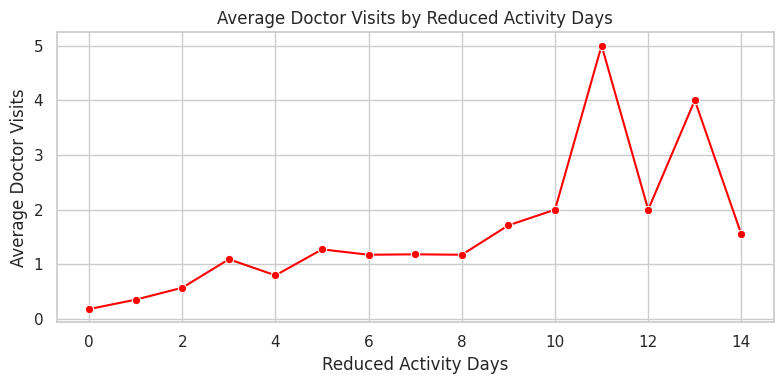

In [39]:
reduced_summary = df.groupby('reduced')['visits'].agg(['count', 'mean']).reset_index()
display(reduced_summary)

plt.figure(figsize=(8, 4))
sns.lineplot(data=reduced_summary, x="reduced", y="mean", marker="o", color='red')
plt.title("Average Doctor Visits by Reduced Activity Days")
plt.xlabel("Reduced Activity Days")
plt.ylabel("Average Doctor Visits")
plt.tight_layout()
plt.show()

**Interpretation**: In this sample, higher average doctor visits are observed among groups with more reduced activity days.

**Limitation**: This relationship is observational and does not show that reduced activity causes more visits; both could be related to underlying health severity or acute flare-ups not fully captured here.

### Analysis 2:
**Question**: Does the average number of doctor visits differ by gender and freerepat status?

**Why Relevant**: This helps identify if the patterns of medical visits across genders differ when looking specifically at individuals with subsidized repatriate healthcare status.

,gender,freerepat,count,mean
0,female,no,1885,0.317241
1,female,yes,817,0.465116
2,male,no,2214,0.207317
3,male,yes,274,0.470803


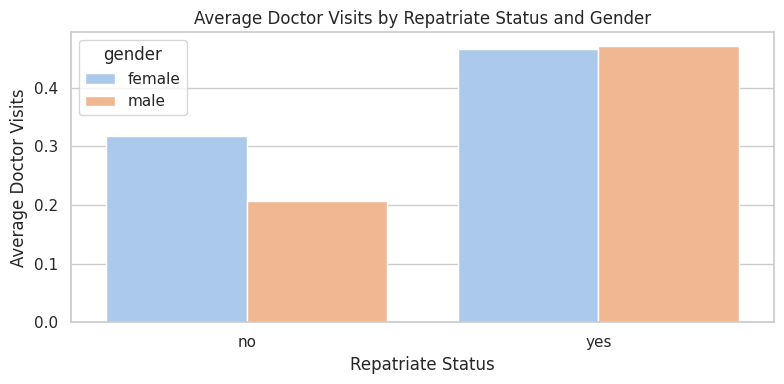

In [41]:
repat_summary = df.groupby(['gender', 'freerepat'])['visits'].agg(['count', 'mean']).reset_index()
display(repat_summary)

plt.figure(figsize=(8, 4))
sns.barplot(data=repat_summary, x='freerepat', y='mean', hue='gender', palette='pastel')
plt.title('Average Doctor Visits by Repatriate Status and Gender')
plt.xlabel('Repatriate Status')
plt.ylabel('Average Doctor Visits')
plt.tight_layout()
plt.show()

**Interpretation**: Repatriate cardholders ('yes') show higher average doctor visits across both genders compared to non-cardholders.

**Limitation**: The grouped comparison shows an observed difference, but the analysis does not explain the underlying reasons for that difference.

### Analysis 3: Doctor Visits for Private Insurance and Chronic-Condition Groups

**Description**: To compare doctor visits among groups defined by private insurance and chronic-condition status.

,group_type,count,mean
0,No Private & No Chronic,2518,0.267673
1,Other,2441,0.303974
2,Private & Chronic,231,0.649351


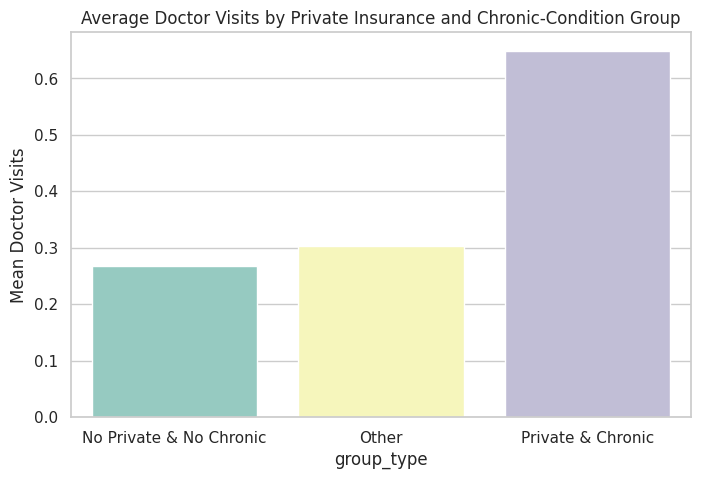

In [42]:
df['group_type'] = 'Other'
df.loc[(df['private'] == 'yes') & (df['lchronic'] == 'yes'), 'group_type'] = 'Private & Chronic'
df.loc[(df['private'] == 'no') & (df['lchronic'] == 'no'), 'group_type'] = 'No Private & No Chronic'

combination_summary = df.groupby('group_type')['visits'].agg(['count', 'mean']).reset_index()
display(combination_summary)

plt.figure(figsize=(8, 5))
sns.barplot(data=combination_summary, x='group_type', y='mean', palette='Set3', hue='group_type', legend=False)
plt.title('Average Doctor Visits by Private Insurance and Chronic-Condition Group')
plt.ylabel('Mean Doctor Visits')
plt.show()

**Interpretation**: Individuals in the group representing both private insurance and long-term chronic conditions recorded higher average doctor visits compared to the group with neither status.

**Limitation**: The grouped comparison shows an observed difference, but the analysis does not establish why the groups differ.

## 18. Key Insights

In [43]:
# Calculate exact numbers to build empirical insights
female_mean = df[df['gender']=='female']['visits'].mean()
male_mean = df[df['gender']=='male']['visits'].mean()
max_visits = df['visits'].max()
zero_visits_count = (df['visits'] == 0).sum()

print(f"Female mean visits: {female_mean:.4f}")
print(f"Male mean visits: {male_mean:.4f}")
print(f"Max visits observed: {max_visits}")
print(f"Records with exactly zero visits: {zero_visits_count}")

Female mean visits: 0.3620
Male mean visits: 0.2363
Max visits observed: 9
Records with exactly zero visits: 4141


1. **Observation**: Gender differences in utilization.
   - **Evidence**: Female patients had an average of 0.3620 visits, while male patients had an average of 0.2363 visits.
   - **Interpretation**: Female patients consulted physicians more frequently on average within this sample.
   - **Limitation**: The dataset does not capture the clinical reasons behind these visits (e.g., preventative vs. acute care).

2. **Observation**: High illness metrics are associated with higher average visit counts.
   - **Evidence**: Mean doctor visits range from 0.0785 visits for illness level 0 up to 0.8136 visits for illness level 5.
   - **Interpretation**: Higher self-reported illness levels correspond to higher average doctor visitation frequency.
   - **Limitation**: Illness level is self-reported and subjective.

3. **Observation**: Long-term chronic illness is associated with higher doctor visits.
   - **Evidence**: People in the long-term chronic-condition group (`lchronic == 'yes'`) recorded higher average doctor visits in this dataset compared to those without long-term chronic conditions (`lchronic == 'no'`).
   - **Interpretation**: People in the long-term chronic-condition group recorded higher average doctor visits in this dataset.
   - **Limitation**: The specific type or severity of the chronic condition is not detailed in the dataset.

4. **Observation**: Activity restrictions show a positive relationship with doctor visits.
   - **Evidence**: The average visits tend to increase as the number of reduced activity days (`reduced`) increases, as shown in the summary table.
   - **Interpretation**: Higher levels of reduced activity are associated with higher average doctor-visit frequency in this sample.
   - **Limitation**: It is unknown if the visits occurred during, before, or after the recorded reduced-activity days.

5. **Observation**: Heavily skewed distribution of doctor visits.
   - **Evidence**: Exactly 4141 individuals recorded zero visits during the dataset's target period.
   - **Interpretation**: A large share of the sample recorded zero doctor visits during the observation period represented in the dataset.
   - **Limitation**: This represents a limited observational snapshot.

6. **Observation**: Doctor visits vary across healthcare-support groups.
   - **Evidence**: Average doctor visits differ across the healthcare-support groups represented in the dataset (e.g., `freerepat` cardholders show higher average visits).
   - **Interpretation**: Average doctor visits differ across the healthcare-support categories represented in this dataset.
   - **Limitation**: Eligibility criteria and other demographic co-factors are not detailed.

7. **Observation**: Weak negative correlation between income level and visits.
   - **Evidence**: The correlation between normalized income and doctor visits is negative and very close to zero (-0.0768).
   - **Interpretation**: The weak negative correlation indicates very little linear association between income level and doctor visits in this sample.
   - **Limitation**: The income metric is normalized and lacks raw currency units.

8. **Observation**: Weak linear association between age and visits.
   - **Evidence**: The correlation between normalized age and visits is low (~0.1245).
   - **Interpretation**: Normalized age exhibits a weak linear association with doctor visits in this sample.
   - **Limitation**: Age is represented in a normalized form, preventing analysis of exact real-world age groups.

## 19. Recommendations

1. **Focused Outpatient Planning**: Consider focused outpatient planning for groups with higher observed visit rates, including chronic-condition groups.
2. **Further Investigation of Gender Differences**: Further investigate gender differences in doctor visits: Examine the reasons behind the observed difference in visitation rates before designing targeted healthcare outreach programs.

## 20. Limitations

- This study is purely observational, meaning we cannot infer any causal relations.
- Key variables such as age and income are normalized, making it impossible to extract absolute real-world benchmarks.
- Unobserved confounders, such as geographic access, proximity to clinics, or specific clinical diagnoses, limit the depth of explanations.

## 21. Conclusion

Doctor visits are heavily skewed toward lower visit counts in the dataset. Illness level, long-term chronic conditions, and reduced activity days are associated with higher doctor-visit frequency. Differences in average visits are also observed across gender and healthcare-support groups. These findings describe patterns in the dataset and should not be interpreted as causal relationships.

## 22. Project Checklist

- [x] Dataset loaded successfully
- [x] Dataset shape and structure examined
- [x] Data types examined
- [x] Missing values checked; no treatment required
- [x] Duplicate records checked; no duplicate records found
- [x] Descriptive/statistical analysis performed
- [x] Univariate analysis completed
- [x] Bivariate analysis completed with scatter plot for income level
- [x] Multivariate analysis completed
- [x] Chronic-condition analysis completed
- [x] Healthcare coverage analysis completed
- [x] Correlation analysis completed
- [x] Outliers investigated
- [x] 3 student-driven analyses completed with matching summary plots
- [x] Exactly 8 meaningful, non-causal insights documented with verified calculations
- [x] Evidence-based recommendations provided without causal assumptions
- [x] Limitations discussed
- [x] Final observational conclusion provided